In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
# Load the dataset
file_path = r"C:\Users\Dell\Documents\Modified_Crime_Dataset.csv"
data = pd.read_csv(file_path)

# Display basic info about the dataset
print("Dataset Info:")
print(data.info())
print("\nFirst Few Rows:")
print(data.head())

# 1. Data Transformation: Normalize Numerical Columns
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
scaler = MinMaxScaler()
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])
print("\nNormalized Data (First Few Rows):")
print(data[numerical_cols].head())

# 2. Encoding Categorical Data
# One-hot encode STATE/UT and DISTRICT
categorical_cols = ['STATE/UT', 'DISTRICT']
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
print("\nEncoded Data (First Few Rows):")
print(data_encoded.head())

# 3. Aggregation and Grouping: Summarize by YEAR and STATE/UT
crime_summary_by_year_state = data.groupby(['YEAR', 'STATE/UT']).sum().reset_index()
print("\nCrime Summary by Year and State (First Few Rows):")
print(crime_summary_by_year_state.head())

# 4. Interaction Features: Combine related features
if 'RAPE' in data.columns and 'OTHER RAPE' in data.columns:
    data_encoded['TOTAL_RAPE'] = data['RAPE'] + data['OTHER RAPE']
    print("\nInteraction Feature - TOTAL_RAPE (First Few Rows):")
    print(data_encoded[['RAPE', 'OTHER RAPE', 'TOTAL_RAPE']].head())
else:
    print("Columns 'RAPE' or 'OTHER RAPE' not found, skipping interaction feature creation.")

# 5. Binning: Group TOTAL IPC CRIMES into severity levels
if 'TOTAL IPC CRIMES' in data.columns:
    bins = [0, 10000, 50000, 100000, np.inf]
    labels = ['Low', 'Moderate', 'High', 'Very High']
    data_encoded['CRIME_SEVERITY'] = pd.cut(data['TOTAL IPC CRIMES'], bins=bins, labels=labels)
    print("\nBinned Data - CRIME_SEVERITY (First Few Rows):")
    print(data_encoded[['TOTAL IPC CRIMES', 'CRIME_SEVERITY']].head())
else:
    print("Column 'TOTAL IPC CRIMES' not found, skipping binning.")

# Save the processed dataset
output_path = r"C:\Users\Dell\Documents\Processed Modified_Crime_Dataset.csv"
data_encoded.to_csv(output_path, index=False)
print(f"\nProcessed dataset saved to: {output_path}")


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9017 entries, 0 to 9016
Columns: 871 entries, YEAR to TOTAL_RAPE
dtypes: bool(841), float64(30)
memory usage: 9.3 MB
None

First Few Rows:
   YEAR    MURDER  ATTEMPT TO MURDER  \
0   0.0  0.013288           0.007534   
1   0.0  0.019866           0.015696   
2   0.0  0.013288           0.007157   
3   0.0  0.010525           0.006655   
4   0.0  0.010788           0.008413   

   CULPABLE HOMICIDE NOT AMOUNTING TO MURDER      RAPE  CUSTODIAL RAPE  \
0                                   0.010520  0.014599             0.0   
1                                   0.000619  0.006715             0.0   
2                                   0.001238  0.007883             0.0   
3                                   0.000619  0.005839             0.0   
4                                   0.000619  0.006715             0.0   

   OTHER RAPE  KIDNAPPING & ABDUCTION  \
0    0.014599                0.005181   
1    0.006715                

KeyError: "None of [Index(['STATE/UT', 'DISTRICT'], dtype='object')] are in the [columns]"

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2, mutual_info_regression
from sklearn.preprocessing import MinMaxScaler

# =============================
# Load Dataset
# =============================
file_path = r"C:\Users\Dell\Documents\Modified_Crime_Dataset.csv"
data = pd.read_csv(file_path)

# Recreate 'Total_Crimes' column if it doesn't exist
if 'Total_Crimes' not in data.columns:
    crime_columns = data.columns[3:]  # Adjust based on your dataset
    data['Total_Crimes'] = data[crime_columns].sum(axis=1)

# Define features (X) and target variable (y)
X = data.drop(columns=['Total_Crimes'])  # Features
y = data['Total_Crimes']  # Target variable

# Ensure all features are numeric
X = pd.get_dummies(X, drop_first=True)

In [17]:
# 1. Variance Threshold
# =============================
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

# Check variance of all features before applying threshold
feature_variances = X.var()
print("\nFeature Variances (Before Scaling):")
print(feature_variances)

# Lower the threshold for variance
threshold = 0.01  # Reduced variance threshold

# Standardize features for more meaningful variance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply VarianceThreshold
selector = VarianceThreshold(threshold)
X_high_variance = selector.fit_transform(X_scaled)

# Extract selected features
selected_features_var = X.columns[selector.get_support()].tolist()
print("\nSelected Features using Variance Threshold (After Scaling):", selected_features_var)

# If no features are selected, check for features with low variance for debugging
if not selected_features_var:
    low_variance_features = feature_variances[feature_variances < threshold]
    print("\nFeatures with Low Variance:")
    print(low_variance_features)



Feature Variances (Before Scaling):
YEAR                                         0.099146
MURDER                                       0.001854
ATTEMPT TO MURDER                            0.001452
CULPABLE HOMICIDE NOT AMOUNTING TO MURDER    0.001357
RAPE                                         0.003101
                                               ...   
DISTRICT_YADGIRI                             0.000333
DISTRICT_YAMUNANAGAR                         0.001329
DISTRICT_YAVATMAL                            0.001329
DISTRICT_ZUNHEBOTO                           0.001329
TOTAL_RAPE                                   0.012405
Length: 871, dtype: float64

Selected Features using Variance Threshold (After Scaling): ['YEAR', 'MURDER', 'ATTEMPT TO MURDER', 'CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE', 'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS', 'KIDNAPPING AND ABDUCTION OF OTHERS', 'DACOITY', 'PREPARATION AND ASSEMBLY FOR DAC

In [9]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, chi2

# =============================
# Load Dataset
# =============================
file_path = r"C:\Users\Dell\Documents\Modified_Crime_Dataset.csv"
data = pd.read_csv(file_path)

# Recreate 'Total_Crimes' column if it doesn't exist
if 'Total_Crimes' not in data.columns:
    crime_columns = data.columns[3:]  # Adjust based on your dataset
    data['Total_Crimes'] = data[crime_columns].sum(axis=1)

# Define features (X) and target variable (y)
X = data.drop(columns=['Total_Crimes', 'STATE/UT', 'DISTRICT', 'YEAR'], errors='ignore')  # Drop non-numeric columns
y = data['Total_Crimes']

# =============================
# Chi-Square Test
# =============================
# Discretize the target variable into 4 bins
y_binned = pd.qcut(y, 4, labels=False, duplicates='drop')

# Discretize numeric features
def discretize_column(col):
    if len(col.unique()) > 4:  # Only discretize if there are enough unique values
        return pd.qcut(col, 4, labels=False, duplicates='drop')
    return col

X_discretized = X.apply(discretize_column)

# Select top 4 features using the chi-squared test
chi_selector = SelectKBest(chi2, k=4)
X_chi2 = chi_selector.fit_transform(X_discretized, y_binned)

# Get selected feature names
selected_features_chi2 = X_discretized.columns[chi_selector.get_support()].tolist()
print("Selected Features using Chi-Square Test:", selected_features_chi2)


Selected Features using Chi-Square Test: ['RAPE', 'OTHER RAPE', 'THEFT', 'TOTAL_RAPE']



Feature Importance using Mutual Information:
                                              Feature  MI Score
13                                              THEFT  0.372469
6                              KIDNAPPING & ABDUCTION  0.371510
5                                          OTHER RAPE  0.339027
0                                              MURDER  0.338636
28                                         TOTAL_RAPE  0.337268
3                                                RAPE  0.336831
18                                           CHEATING  0.328957
7         KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS  0.326396
25                CRUELTY BY HUSBAND OR HIS RELATIVES  0.316292
15                                        OTHER THEFT  0.315552
14                                         AUTO THEFT  0.315160
11                                            ROBBERY  0.267658
23  ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MO...  0.265992
12                                           BURGLARY  0.2

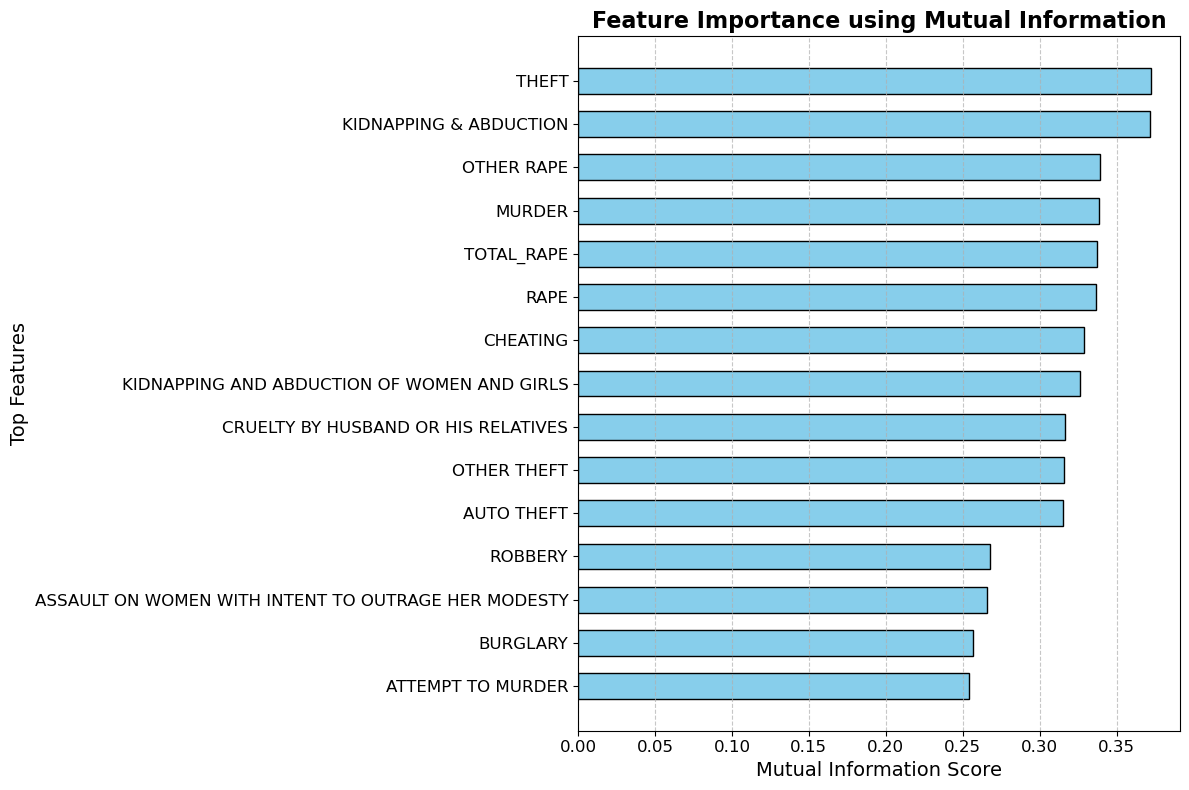

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import mutual_info_regression

# =============================
# Load Dataset
# =============================
file_path = r"C:\Users\Dell\Documents\Modified_Crime_Dataset.csv"
data = pd.read_csv(file_path)

# Filter the dataset to keep only state-level data
# Drop 'DISTRICT' column if it exists
data = data.drop(columns=['DISTRICT'], errors='ignore')

# Recreate 'Total_Crimes' column if it doesn't exist
if 'Total_Crimes' not in data.columns:
    crime_columns = data.select_dtypes(include=['int64', 'float64']).columns
    data['Total_Crimes'] = data[crime_columns].sum(axis=1)

# Define features (X) and target variable (y)
# Drop columns that are not meaningful for feature selection
X = data.drop(columns=['Total_Crimes', 'STATE/UT', 'YEAR'], errors='ignore')  # Keep numeric features only
y = data['Total_Crimes']

# Ensure all features are numeric
X = X.select_dtypes(include=['int64', 'float64'])

# =============================
# Mutual Information Calculation
# =============================
# Scale the features to [0, 1] for MI calculation
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Calculate mutual information scores
mi_scores = mutual_info_regression(X_scaled, y, random_state=42)
mi_df = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores})
mi_df = mi_df.sort_values(by='MI Score', ascending=False)

print("\nFeature Importance using Mutual Information:")
print(mi_df)

# =============================
# Improved Visualization
# =============================
# Filter top 15 features for better readability
top_features = mi_df.head(15)

plt.figure(figsize=(12, 8))  # Increase figure size for better clarity
plt.barh(top_features['Feature'], top_features['MI Score'], color='skyblue', edgecolor='black', height=0.6)  # Tighter bars
plt.xlabel('Mutual Information Score', fontsize=14)
plt.ylabel('Top Features', fontsize=14)
plt.title('Feature Importance using Mutual Information', fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)  # Add light grid lines for x-axis
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.tight_layout()  # Adjust layout to avoid clipping
plt.show()


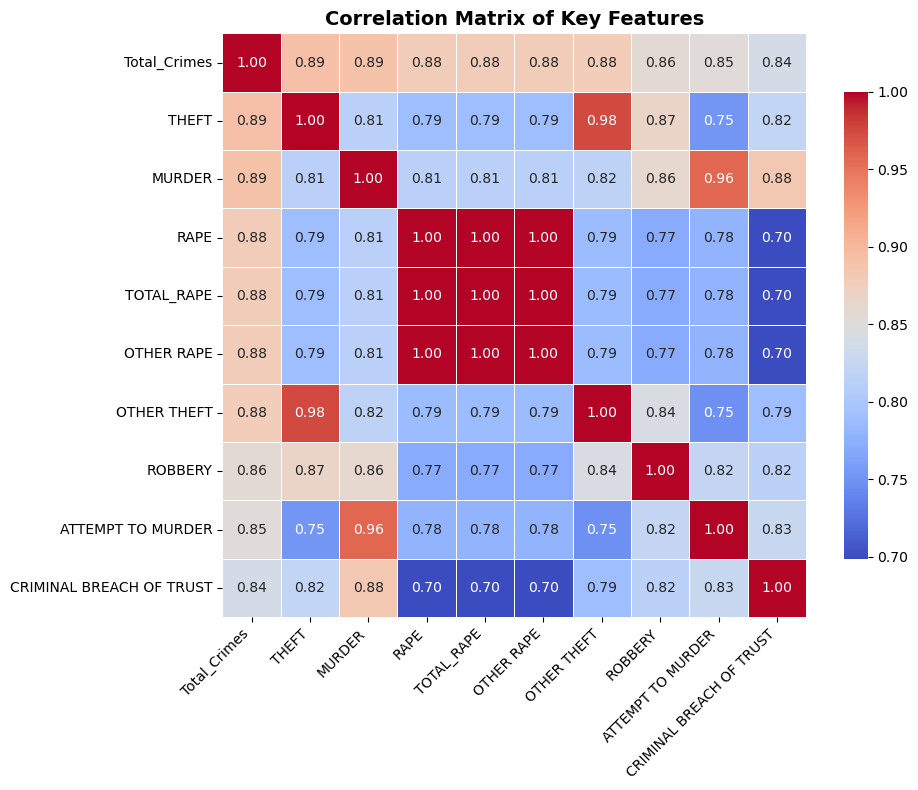

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the correlation matrix
correlation_matrix = pd.concat([X, y], axis=1).corr()

# Filter top features to focus on the most relevant relationships (optional)
top_features = correlation_matrix.abs().nlargest(10, 'Total_Crimes')['Total_Crimes'].index
filtered_correlation_matrix = correlation_matrix.loc[top_features, top_features]

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))  # Adjust figure size for better clarity

# Draw the heatmap
sns.heatmap(
    filtered_correlation_matrix,
    cmap='coolwarm',  # Use a clean color palette
    annot=True,  # Annotate with correlation values
    fmt=".2f",  # Limit decimals for neatness
    linewidths=0.5,  # Add thin lines between boxes
    square=True,  # Keep cells square for consistency
    cbar_kws={"shrink": 0.8},  # Shrink the color bar
    annot_kws={"size": 10}  # Adjust font size for annotations
)

# Set the title and axis labels
plt.title('Correlation Matrix of Key Features', fontsize=14, fontweight='bold')
plt.xticks(fontsize=10, rotation=45, ha='right')  # Rotate x-axis labels
plt.yticks(fontsize=10)  # Adjust y-axis label size
plt.tight_layout()  # Ensure everything fits neatly
plt.show()
